# Bloque 0: Librerías

In [ ]:
# =========================================================
# BLOQUE 1. CARGUE DE PAQUETES
# =========================================================
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import operator

from statsmodels.tsa.stattools import acf, pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from scipy.stats import jarque_bera, shapiro, normaltest
from statsmodels.stats.outliers_influence import variance_inflation_factor
import json
import openpyxl
from openpyxl.packaging.custom import StringProperty

# Bloque 1: Configuración y lectura de archivos


## 1.1. Configuración

In [ ]:
# ==========================================
# Fecha de inicio luego del cálculo de las variaciones
# ==========================================

FECHA_INICIO = "2018-10-01"

# ==========================================
# FECHA FIN DEL HISTÓRICO
# ==========================================

FECHA_FIN_HIST = "2025-03-01"

# ==========================================
# Nombre columnas de fecha
# ==========================================

COLUMNA_ACTUAL_EXO = "fecha"
COLUMNA_ACTUAL_ENDO = "fecha_corte"

# ==========================================
# Nombre de la endógena
# ==========================================

VAR_ENDO ="total"
# ==========================================
# País y cartera de esta corrida (EDITAR EN CADA EJECUCIÓN)
# ==========================================

PAIS = "CO"       # ej: "CO", "PA"
CARTERA = "vivi"  # ej: "cons", "tc", "vehic", "hipo", "comercial"

# ==========================================
# ==========================================
# Variables que son TASAS (ya vienen en % / puntos)
# ------------------------------------------
# Estas NO usan variación porcentual (pct_change) sino DIFERENCIA ABSOLUTA
# (diff = cambio en puntos porcentuales). Evita el "blow-up" del pct_change
# cuando la serie se acerca o cruza cero (inflación, desempleo, etc.).
# Escribe el NOMBRE BASE de la columna del archivo macro, en minúsculas y
# SIN el sufijo de escenario (_opt/_bas/_adv). El resto de variables
# (niveles / índices: pib, ipc, ...) siguen usando pct_change.
# ==========================================



VARIABLES_TASA = [
    "prom_trim_desempleo",
    "promtriminflacion",
]

# ==========================================
# Modo de cálculo de la endógena
# ------------------------------------------
# "actual"          -> usa el valor original de la endógena (cálculo actual)
# "media_movil"     -> usa la media móvil de la endógena
#
# VENTANA_MEDIA_MOVIL: número de meses de la ventana (3 = media móvil trimestral)
# ==========================================

MODO_ENDO = "media_movil"          # "actual" | "media_movil"
VENTANA_MEDIA_MOVIL = 3

# ==========================================
# Nombre archivo con información histórica
# ==========================================

NOMBRE_ARCHIVO_HIST = "hist_vivi_co_fwl_pd12.xlsx"

# ==========================================
# Nombre archivo con proyección optimista
# ==========================================

NOMBRE_ARCHIVO_OPT = "opt_macro_davi__vivi_co_fwl_pd12.xlsx"

# ==========================================
# Nombre archivo con proyección histórica
# ==========================================

NOMBRE_ARCHIVO_BASE = "bas_macro_davi_vivi_co_fwl_pd12.xlsx"

# ==========================================
# Nombre archivo con proyección histórica
# ==========================================

NOMBRE_ARCHIVO_ADV = "adv_macro_davi__vivi_co_fwl_pd12.xlsx"

## 1.2. Carga, lectura e interpolación de archivos

In [ ]:
# Cargar archivo
exo = pd.read_excel('Variables Macro FWL CO.xlsx')

# ==========================================
# RENOMBRAR COLUMNA
# ==========================================

exo = exo.rename(
    columns={
        COLUMNA_ACTUAL_EXO: "fecha"
    }
)

# Convertir fecha e indexar
exo['fecha'] = pd.to_datetime(exo['fecha'])
exo = exo.set_index('fecha')

# Crear todas las fechas mensuales entre la mínima y máxima fecha
exo = exo.asfreq('MS')  # MS = inicio de mes

# Interpolación lineal
exo_interpolado = exo.interpolate(method='linear')

print(exo_interpolado.tail(20))

                  pib_opt        pib_bas        pib_adv     ipc_opt  \
fecha                                                                 
2027-05-01  259445.623894  258011.723157  256819.948913  165.744912   
2027-06-01  261932.816870  260084.616001  258537.962376  166.286644   
2027-07-01  264742.383389  262727.606201  261184.259458  166.680082   
2027-08-01  267551.949907  265370.596401  263830.556540  167.073519   
2027-09-01  270361.516426  268013.586601  266476.853623  167.466957   
2027-10-01  274873.658160  272590.401838  271012.053541  167.778474   
2027-11-01  279385.799893  277167.217076  275547.253459  168.089991   
2027-12-01  283897.941627  281744.032313  280082.453377  168.401508   
2028-01-01  275912.755747  274103.256414  272654.327571  169.646698   
2028-02-01  267927.569867  266462.480515  265226.201766  170.891888   
2028-03-01  259942.383987  258821.704615  257798.075961  172.137078   
2028-04-01  262828.105136  261156.975595  259564.369363  172.620261   
2028-0

In [ ]:
# Cargar archivo
endo = pd.read_csv('test_pd_lra_vivi_01mar26.csv')

# ==========================================
# RENOMBRAR COLUMNA
# ==========================================

endo = endo.rename(
    columns={
        COLUMNA_ACTUAL_ENDO: "fecha"
    }
)

# Conservar solo fecha y total
endo = endo[["fecha", VAR_ENDO]].rename(
    columns={VAR_ENDO: "ENDÓGENA"}
)

# Convertir fecha e indexar
endo["fecha"] = pd.to_datetime(endo["fecha"])
endo = endo.set_index("fecha")

# Crear frecuencia mensual
endo = endo.asfreq("MS")

# ==========================================
# CÁLCULO DE LA ENDÓGENA (parametrizable)
# ------------------------------------------
# MODO_ENDO == "actual"      -> valor original
# MODO_ENDO == "media_movil" -> media móvil de VENTANA_MEDIA_MOVIL meses
# ==========================================

if MODO_ENDO == "media_movil":
    endo["ENDÓGENA"] = (
        endo["ENDÓGENA"]
        .rolling(window=VENTANA_MEDIA_MOVIL, min_periods=VENTANA_MEDIA_MOVIL)
        .mean()
    )
    print(
        f"Endógena calculada como media móvil de {VENTANA_MEDIA_MOVIL} meses."
    )
elif MODO_ENDO == "actual":
    print("Endógena calculada con el valor actual (sin media móvil).")
else:
    raise ValueError(
        f"MODO_ENDO='{MODO_ENDO}' no válido. Use 'actual' o 'media_movil'."
    )

print(endo)

Endógena calculada como media móvil de 3 meses.
            ENDÓGENA
fecha               
2018-10-01       NaN
2018-11-01       NaN
2018-12-01  0.023511
2019-01-01  0.023395
2019-02-01  0.023186
...              ...
2024-11-01  0.012325
2024-12-01  0.011955
2025-01-01  0.011697
2025-02-01  0.011556
2025-03-01  0.011429

[78 rows x 1 columns]


In [ ]:
# =========================================================
# VARIACIONES DE LAS EXÓGENAS  (tratamiento por tipo de variable)
# ---------------------------------------------------------
# Regla (ver VARIABLES_TASA en la celda de configuración):
#   - NIVEL / ÍNDICE (p. ej. PIB, IPC): variación PORCENTUAL  -> pct_change()
#   - TASA (p. ej. inflación, desempleo): DIFERENCIA ABSOLUTA -> diff()
#     (cambio en puntos porcentuales). Evita el "blow-up" del pct_change
#     cuando la serie se acerca o cruza cero.
# =========================================================

def _nombre_base(col):
    """Quita el sufijo de escenario (_opt/_bas/_adv) -> nombre base en minúsculas."""
    base = col.lower()
    for suf in ("_opt", "_bas", "_adv"):
        if base.endswith(suf):
            return base[: -len(suf)]
    return base

def _es_tasa(col):
    """True si la columna es una variable-tasa (usa diff en vez de pct_change)."""
    return _nombre_base(col) in [v.lower() for v in VARIABLES_TASA]

def calcular_variacion(df, periodos):
    """Variación a 'periodos': pct_change para niveles, diff para tasas (por columna)."""
    salida = pd.DataFrame(index=df.index)
    for col in df.columns:
        if _es_tasa(col):
            salida[col] = df[col].diff(periodos)         # cambio en puntos (tasas)
        else:
            salida[col] = df[col].pct_change(periodos)   # variación % (niveles)
    return salida

# Variaciones (mensual = 1, trimestral = 3, anual = 12)
var_mensual = calcular_variacion(exo_interpolado, 1)
var_trimestral = calcular_variacion(exo_interpolado, 3)
var_anual = calcular_variacion(exo_interpolado, 12)

# Reporte de la clasificación aplicada (trazabilidad)
_tasas = sorted({_nombre_base(c) for c in exo_interpolado.columns if _es_tasa(c)})
_niveles = sorted({_nombre_base(c) for c in exo_interpolado.columns if not _es_tasa(c)})
print("Tratamiento de variaciones:")
print(f"   TASAS   (diff, Δ puntos)    : {_tasas}")
print(f"   NIVELES (pct_change, % var) : {_niveles}")

# Renombrar columnas
var_mensual.columns = [f'var_mensual_{col}' for col in var_mensual.columns]
var_trimestral.columns = [f'var_trimestral_{col}' for col in var_trimestral.columns]
var_anual.columns = [f'var_anual_{col}' for col in var_anual.columns]

# Unir todo en un solo DataFrame
exo_variaciones = pd.concat(
    [var_mensual, var_trimestral, var_anual],
    axis=1
)

exo_variaciones = (
    exo_variaciones.dropna(how='all').copy()
)

exo_variaciones = exo_variaciones[
    exo_variaciones.index >= pd.Timestamp(FECHA_INICIO)
]

exo_variaciones.columns = exo_variaciones.columns.str.upper()

print(exo_variaciones.head(20))

Tratamiento de variaciones:
   TASAS   (diff, Δ puntos)    : ['prom_trim_desempleo']
   NIVELES (pct_change, % var) : ['ipc', 'pib']
            VAR_MENSUAL_PIB_OPT  VAR_MENSUAL_PIB_BAS  VAR_MENSUAL_PIB_ADV  \
fecha                                                                       
2018-10-01             0.016691             0.016691             0.016691   
2018-11-01             0.016417             0.016417             0.016417   
2018-12-01             0.016152             0.016152             0.016152   
2019-01-01            -0.027773            -0.027773            -0.027773   
2019-02-01            -0.028566            -0.028566            -0.028566   
2019-03-01            -0.029406            -0.029406            -0.029406   
2019-04-01             0.011775             0.011775             0.011775   
2019-05-01             0.011638             0.011638             0.011638   
2019-06-01             0.011504             0.011504             0.011504   
2019-07-01          

In [ ]:
# ==========================================
# VARIABLES BASE HISTÓRICAS
# ==========================================

exo_hist = exo_variaciones.loc[
    :pd.Timestamp(FECHA_FIN_HIST),
    exo_variaciones.columns.str.contains('_BAS')
].copy()

exo_hist.columns = exo_hist.columns.str.replace('_BAS', '', regex=False)

print(exo_hist.head())
print(exo_hist.tail())

            VAR_MENSUAL_PIB  VAR_MENSUAL_IPC  VAR_MENSUAL_PROM_TRIM_DESEMPLEO  \
fecha                                                                           
2018-10-01         0.016691         0.001206                         0.000654   
2018-11-01         0.016417         0.001105                        -0.000965   
2018-12-01         0.016152         0.003009                         0.001035   
2019-01-01        -0.027773         0.006000                         0.011321   
2019-02-01        -0.028566         0.005765                         0.009049   

            VAR_TRIMESTRAL_PIB  VAR_TRIMESTRAL_IPC  \
fecha                                                
2018-10-01            0.039665            0.004134   
2018-11-01            0.044928            0.004028   
2018-12-01            0.050074            0.005328   
2019-01-01            0.004150            0.010142   
2019-02-01           -0.040291            0.014845   

            VAR_TRIMESTRAL_PROM_TRIM_DESEMPLEO  VAR_A

In [ ]:
# ==========================================
# UNIR ENDÓGENA + EXÓGENAS HISTÓRICAS
# ==========================================

df_hist = pd.concat(
    [endo, exo_hist],
    axis=1,
    join='inner'  # solo fechas comunes
)

print(df_hist.head())
print(df_hist.tail())

            ENDÓGENA  VAR_MENSUAL_PIB  VAR_MENSUAL_IPC  \
fecha                                                    
2018-10-01       NaN         0.016691         0.001206   
2018-11-01       NaN         0.016417         0.001105   
2018-12-01  0.023511         0.016152         0.003009   
2019-01-01  0.023395        -0.027773         0.006000   
2019-02-01  0.023186        -0.028566         0.005765   

            VAR_MENSUAL_PROM_TRIM_DESEMPLEO  VAR_TRIMESTRAL_PIB  \
fecha                                                             
2018-10-01                         0.000654            0.039665   
2018-11-01                        -0.000965            0.044928   
2018-12-01                         0.001035            0.050074   
2019-01-01                         0.011321            0.004150   
2019-02-01                         0.009049           -0.040291   

            VAR_TRIMESTRAL_IPC  VAR_TRIMESTRAL_PROM_TRIM_DESEMPLEO  \
fecha                                                

In [ ]:
# ==========================================
# VARIABLES BASE PROYECTADAS
# ==========================================

exo_proy_base = exo_variaciones.loc[
    pd.Timestamp(FECHA_FIN_HIST) + pd.offsets.MonthBegin(1):,
    exo_variaciones.columns.str.contains('_BAS')
].copy()


In [ ]:
# ==========================================
# VARIABLES OPTIMISTA PROYECTADAS
# ==========================================

exo_proy_opti = exo_variaciones.loc[
    pd.Timestamp(FECHA_FIN_HIST) + pd.offsets.MonthBegin(1):,
    exo_variaciones.columns.str.contains('_OPT')
].copy()


In [ ]:
# ==========================================
# VARIABLES ADVERSO PROYECTADAS
# ==========================================

exo_proy_adve = exo_variaciones.loc[
    pd.Timestamp(FECHA_FIN_HIST) + pd.offsets.MonthBegin(1):,
    exo_variaciones.columns.str.contains('_ADV')
].copy()


In [ ]:
# ==========================================
# EXPORTAR HISTÓRICO
# ==========================================

df_hist.to_excel(
    NOMBRE_ARCHIVO_HIST,
    index=True
)

print(f"Archivo guardado: {NOMBRE_ARCHIVO_HIST}")

# ==========================================
# EXPORTAR BASE
# ==========================================

exo_proy_base.to_excel(
    NOMBRE_ARCHIVO_BASE,
    index=True
)

print(f"Archivo guardado: {NOMBRE_ARCHIVO_BASE}")

# ==========================================
# EXPORTAR ADVERSO
# ==========================================

exo_proy_adve.to_excel(
    NOMBRE_ARCHIVO_ADV,
    index=True
)

print(f"Archivo guardado: {NOMBRE_ARCHIVO_ADV}")


# ==========================================
# EXPORTAR OPTIMISTA
# ==========================================

exo_proy_opti.to_excel(
    NOMBRE_ARCHIVO_OPT,
    index=True
)

print(f"Archivo guardado: {NOMBRE_ARCHIVO_OPT}")

Archivo guardado: hist_vivi_co_fwl_pd12.xlsx
Archivo guardado: bas_macro_davi_vivi_co_fwl_pd12.xlsx
Archivo guardado: adv_macro_davi__vivi_co_fwl_pd12.xlsx
Archivo guardado: opt_macro_davi__vivi_co_fwl_pd12.xlsx


In [ ]:
# =====================================================================
# METADATA DE TRAZABILIDAD · se embebe en los 4 Excel ya exportados.
# No crea hojas nuevas ni modifica los datos existentes de ningún archivo.
# =====================================================================

META_GENERADOR = {
    "pais": PAIS,
    "cartera": CARTERA,
    "generador_fecha_inicio": FECHA_INICIO,
    "generador_fecha_fin_hist": FECHA_FIN_HIST,
    "generador_var_endo": VAR_ENDO,
    "generador_variables_tasa": VARIABLES_TASA,
    "generador_modo_endogena": MODO_ENDO,
    "generador_ventana_mm": VENTANA_MEDIA_MOVIL,
}

def _embeber_meta(ruta_archivo, meta_dict, prefix="sarimax_meta_generador"):
    wb = openpyxl.load_workbook(ruta_archivo)
    valor = json.dumps(meta_dict, ensure_ascii=False)
    if f"{prefix}_01" in wb.custom_doc_props.names:
        del wb.custom_doc_props[f"{prefix}_01"]
    if f"{prefix}_n" in wb.custom_doc_props.names:
        del wb.custom_doc_props[f"{prefix}_n"]
    wb.custom_doc_props.append(StringProperty(name=f"{prefix}_01", value=valor))
    wb.custom_doc_props.append(StringProperty(name=f"{prefix}_n", value="1"))
    wb.save(ruta_archivo)

for archivo in [NOMBRE_ARCHIVO_HIST, NOMBRE_ARCHIVO_BASE, NOMBRE_ARCHIVO_ADV, NOMBRE_ARCHIVO_OPT]:
    _embeber_meta(archivo, META_GENERADOR)
    print(f"Metadata embebida en: {archivo}")

Metadata embebida en: hist_vivi_co_fwl_pd12.xlsx
Metadata embebida en: bas_macro_davi_vivi_co_fwl_pd12.xlsx
Metadata embebida en: adv_macro_davi__vivi_co_fwl_pd12.xlsx
Metadata embebida en: opt_macro_davi__vivi_co_fwl_pd12.xlsx


# Bloque 2: Visualización de variables (endógena y exógenas por escenario)

Grafica la **endógena** (histórico) y cada **exógena** (variación ya tratada) en sus
tres escenarios **BAS / ADV / OPT**, al estilo de la *CELDA 3* de
`Motor_Sarimax_Panama.ipynb`. Una línea vertical marca el fin del histórico
(`FECHA_FIN_HIST`) para distinguir histórico de proyección.

Para cada exógena se muestran los tres horizontes (mensual, trimestral, anual). El
eje indica la unidad según el tratamiento aplicado: **% variación** para niveles
(`pct_change`) o **Δ puntos** para tasas (`diff`, ver `VARIABLES_TASA`).

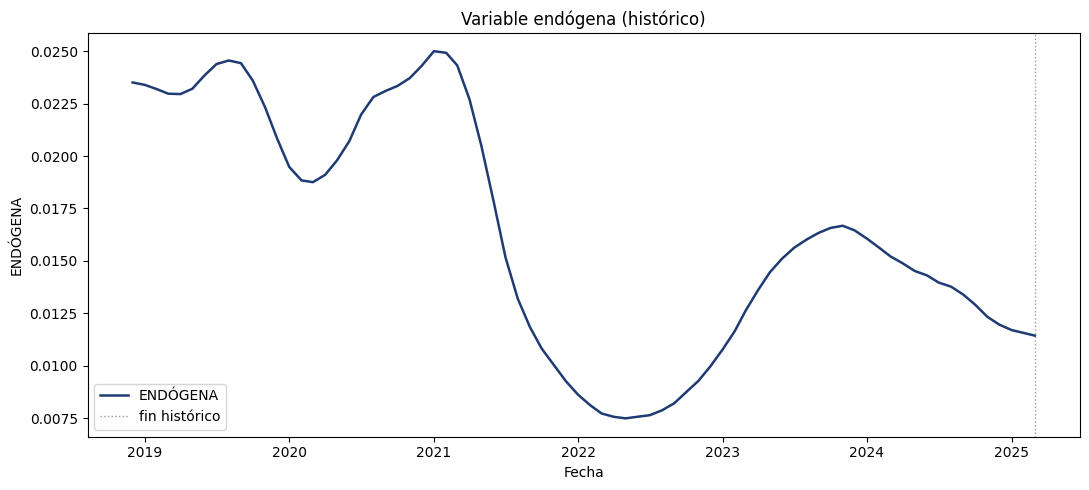

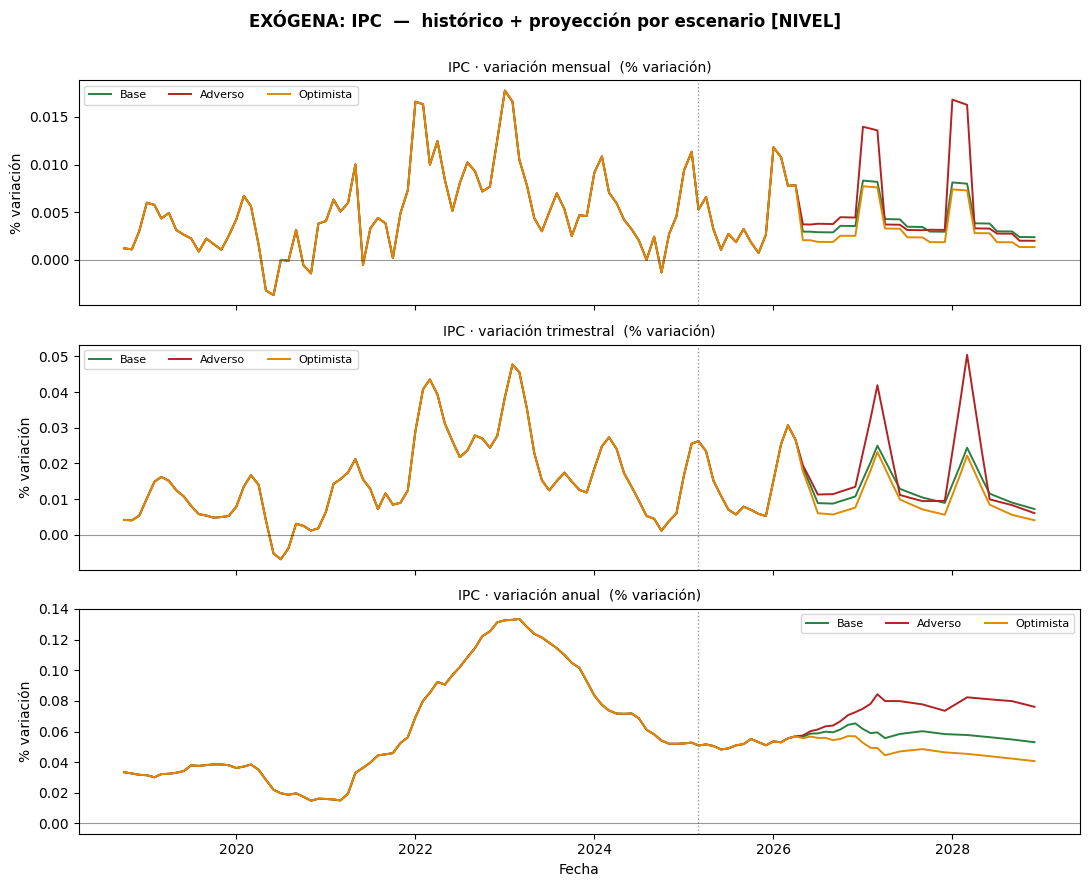

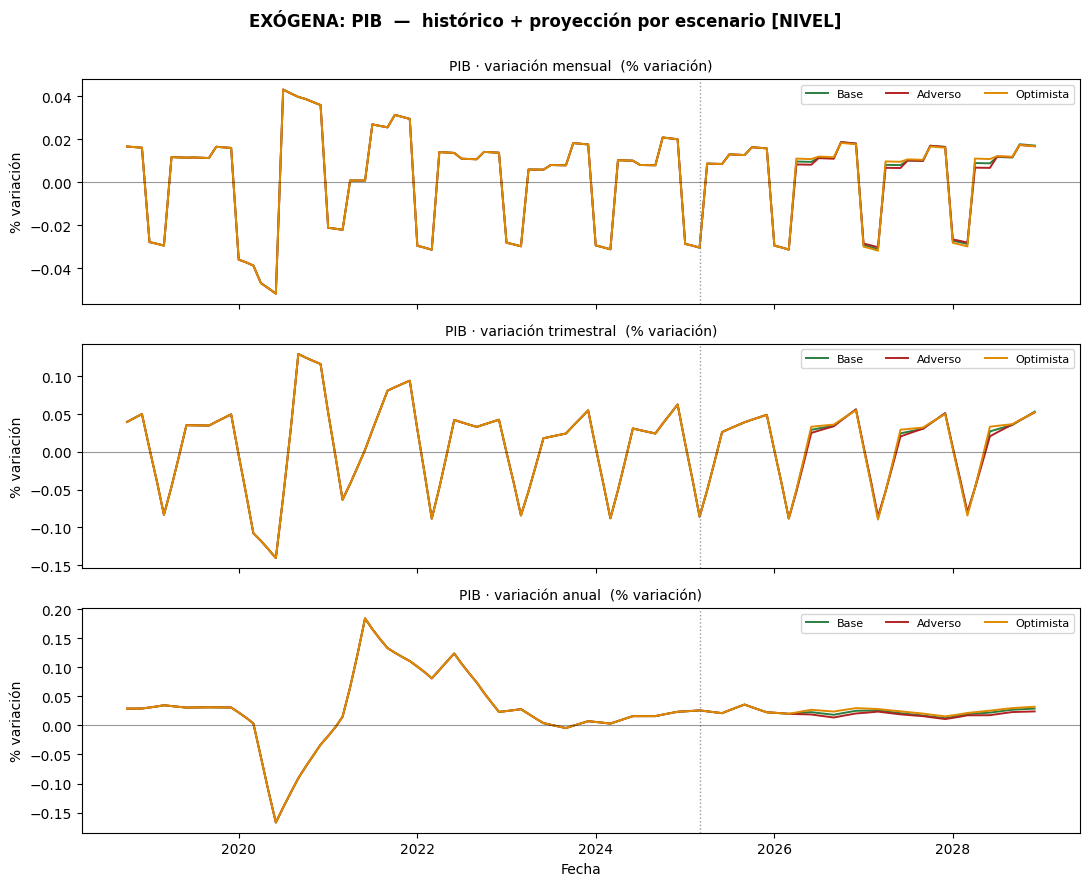

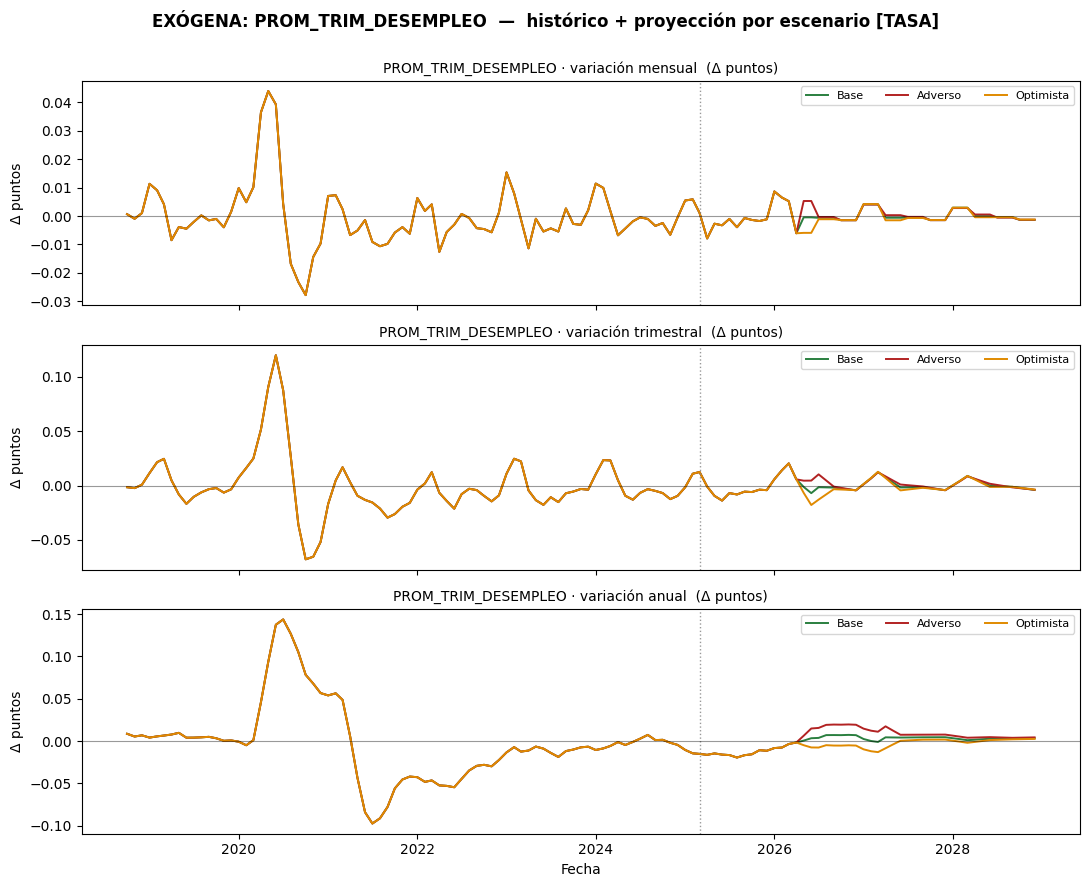

Graficador ejecutado: 1 endógena + 3 exógena(s) × 3 horizonte(s) × 3 escenario(s).


In [ ]:
# =====================================================================
# GRAFICADOR · VARIABLES ENDÓGENA Y EXÓGENAS POR ESCENARIO
# (estilo de la CELDA 3 de Motor_Sarimax_Panama.ipynb)
# ---------------------------------------------------------------------
# Grafica:
#   - la ENDÓGENA (histórico), y
#   - cada EXÓGENA (variación ya tratada) en sus 3 escenarios BAS/ADV/OPT,
#     con una línea vertical que separa el histórico de la proyección
#     (FECHA_FIN_HIST). Sirve para verificar que, tras el tratamiento por
#     tipo (% var para niveles, Δ puntos para tasas), las series salen sin
#     los valores exagerados que producía el pct_change sobre tasas.
# Insumo: 'exo_variaciones' (histórico + proyección) y 'endo'.
# =====================================================================

HORIZONTES = ["MENSUAL", "TRIMESTRAL", "ANUAL"]
ESCENARIOS = ["BAS", "ADV", "OPT"]
colores_esc = {"BAS": "#2a7f3f", "ADV": "#b22222", "OPT": "#e08a00"}
etiquetas_esc = {"BAS": "Base", "ADV": "Adverso", "OPT": "Optimista"}

fecha_corte = pd.Timestamp(FECHA_FIN_HIST)
_tasas_base = [v.lower() for v in VARIABLES_TASA]


def _parsear_columna(col):
    """VAR_{HORIZONTE}_{BASE}_{ESC} -> (horizonte, base, escenario) o None."""
    resto = col[len("VAR_"):] if col.startswith("VAR_") else col
    horizonte = next((h for h in HORIZONTES if resto.startswith(h + "_")), None)
    if horizonte is None:
        return None
    resto = resto[len(horizonte) + 1:]
    escenario = next((e for e in ESCENARIOS if resto.endswith("_" + e)), None)
    if escenario is None:
        return None
    base = resto[: -(len(escenario) + 1)]
    return horizonte, base, escenario


# --- Inventario de variables base presentes en exo_variaciones -------
bases = sorted({
    p[1] for p in (_parsear_columna(c) for c in exo_variaciones.columns) if p
})

# ------------------------- GRÁFICA ENDÓGENA --------------------------
serie_endo = endo["ENDÓGENA"].dropna()
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(serie_endo.index, serie_endo.values, color="#1f3b73", lw=1.8, label="ENDÓGENA")
ax.axvline(fecha_corte, color="grey", ls=":", lw=1, alpha=0.8, label="fin histórico")
ax.set_title("Variable endógena (histórico)")
ax.set_xlabel("Fecha")
ax.set_ylabel("ENDÓGENA")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

# ----- GRÁFICA POR EXÓGENA: un panel por horizonte, 3 escenarios -----
for base in bases:
    es_tasa = base.lower() in _tasas_base
    unidad = "Δ puntos" if es_tasa else "% variación"

    fig, axes = plt.subplots(len(HORIZONTES), 1, figsize=(11, 9), sharex=True)
    for ax, horizonte in zip(axes, HORIZONTES):
        for esc in ESCENARIOS:
            col = f"VAR_{horizonte}_{base}_{esc}"
            if col not in exo_variaciones.columns:
                continue
            s = exo_variaciones[col].dropna()
            ax.plot(s.index, s.values, color=colores_esc[esc], lw=1.4,
                    label=etiquetas_esc[esc])
        ax.axvline(fecha_corte, color="grey", ls=":", lw=1, alpha=0.8)
        ax.axhline(0, color="black", lw=0.8, alpha=0.4)
        ax.set_title(f"{base} · variación {horizonte.lower()}  ({unidad})", fontsize=10)
        ax.set_ylabel(unidad)
        ax.legend(loc="best", fontsize=8, ncol=3)
    axes[-1].set_xlabel("Fecha")
    fig.suptitle(f"EXÓGENA: {base}  —  histórico + proyección por escenario "
                 f"[{'TASA' if es_tasa else 'NIVEL'}]",
                 fontsize=12, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()

print(f"Graficador ejecutado: 1 endógena + {len(bases)} exógena(s) "
      f"× {len(HORIZONTES)} horizonte(s) × {len(ESCENARIOS)} escenario(s).")